# Crime and Housing

In [180]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dataset = pd.read_csv('data/crime-housing-austin-2015.csv')
# Remove housing columns (everything right of Y_Coordinate)
dataset = dataset.loc[:, :'Y_Coordinate']

In [181]:
dataset = dataset.rename(columns={'Highest_NIBRS_UCR_Offense_Description':'UCR_Offense'})
dataset['UCR_Offense'].value_counts()

UCR_Offense
Theft          28274
Burglary        4927
Auto Theft      2018
Agg Assault     1915
Robbery          935
Rape             481
Murder            23
Name: count, dtype: int64

### Merging Weather Data

In [182]:
# Convert to actual date
dataset['Report_Date'] = pd.to_datetime(dataset["Report_Date"], format="%d-%b-%y")
weather_df = pd.read_csv('data/austin_weather.csv')
weather_df['Report_Date'] = pd.to_datetime(weather_df["Date"], format="%Y-%m-%d")
weather_crime = dataset.merge(weather_df, on='Report_Date').reset_index()
weather_crime['PrecipitationSumInches'] = weather_crime['PrecipitationSumInches'].str.replace("T", '0.0').astype(float)

## Heat Maps

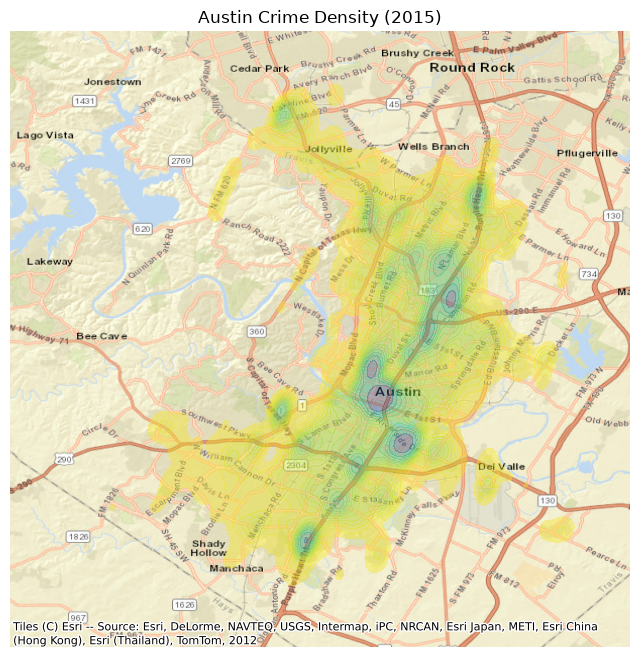

In [183]:
import geopandas as gpd
import contextily as ctx

gdf = gpd.GeoDataFrame(
    weather_crime,
    geometry=gpd.points_from_xy(weather_crime['X_Coordinate'], weather_crime['Y_Coordinate']),
    crs="EPSG:2277" # Define the starting coordinate system (NAD83 / Texas Central)
)

# Project the geometry to standard WGS84 Latitude/Longitude
gdf = gdf.to_crs("EPSG:3857")

# (Optional) Extract the transformed coordinates back into standard columns
gdf['Longitude'] = gdf.geometry.x
gdf['Latitude'] = gdf.geometry.y

fig, ax = plt.subplots(figsize=(8, 8))

# Generate the spatial density plot
sns.kdeplot(
    x=gdf['Longitude'],
    y=gdf['Latitude'],
    cmap="viridis_r",
    fill=True,
    bw_adjust=0.5,      # lower = tighter heat pockets
    alpha=0.4,
    levels=15
)


ctx.add_basemap(ax, source=ctx.providers.Esri.WorldStreetMap)
# ctx.add_basemap(ax, source=ctx.providers.Esri.WorldGrayCanvas)
# ctx.add_basemap(ax, source=ctx.providers.Esri.WorldTopoMap)


ax.set_axis_off()

plt.title("Austin Crime Density (2015)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(False)
plt.show()

Index(['index', 'Key', 'Council_District', 'Highest_Offense_Desc',
       'UCR_Offense', 'Report_Date', 'Location', 'Clearance_Status',
       'Clearance_Date', 'District', 'Zip_Code_Crime', 'Census_Tract',
       'X_Coordinate', 'Y_Coordinate', 'Date', 'TempHighF', 'TempAvgF',
       'TempLowF', 'DewPointHighF', 'DewPointAvgF', 'DewPointLowF',
       'HumidityHighPercent', 'HumidityAvgPercent', 'HumidityLowPercent',
       'SeaLevelPressureHighInches', 'SeaLevelPressureAvgInches',
       'SeaLevelPressureLowInches', 'VisibilityHighMiles',
       'VisibilityAvgMiles', 'VisibilityLowMiles', 'WindHighMPH', 'WindAvgMPH',
       'WindGustMPH', 'PrecipitationSumInches', 'Events', 'geometry',
       'Longitude', 'Latitude'],
      dtype='str')


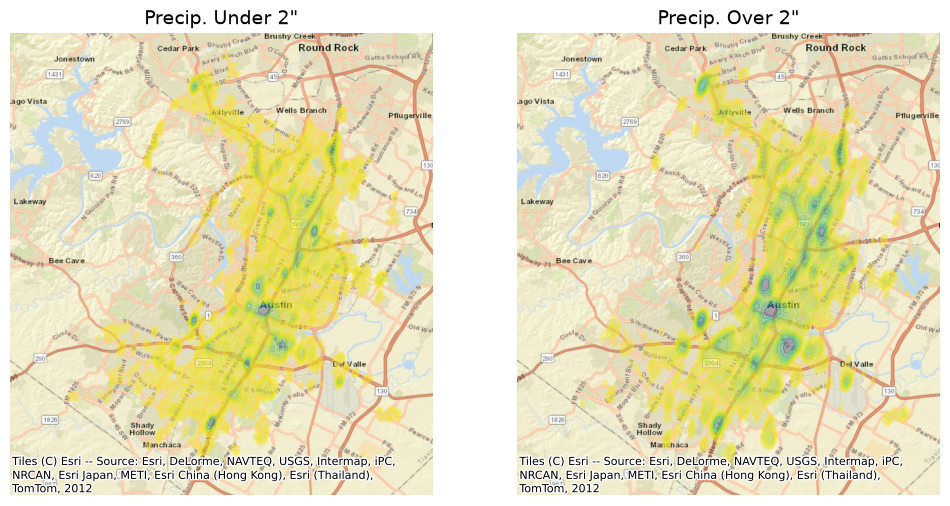

In [224]:

fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

has_rain = gdf.PrecipitationSumInches > 1
print(gdf.columns)

yes_rain_gdf = gdf[has_rain]
no_rain_gdf = gdf[~has_rain]

ax = plt.subplot(1,2,1)
# Generate the spatial density plot
sns.kdeplot(
    x=no_rain_gdf['Longitude'],
    y=no_rain_gdf['Latitude'],
    cmap="viridis_r",
    fill=True,
    bw_adjust=0.2,      # lower = tighter heat pockets
    alpha=0.4,
    levels=15
)
# plt.scatter(x=no_rain_gdf.Longitude, y=no_rain_gdf.Latitude, c='red', alpha=0.05, s=1)
ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.Esri.WorldStreetMap)
ax.set_title(f"Precip. Under 2\"", fontsize=14)
ax.set_axis_off()

ax = plt.subplot(1,2,2)
sns.kdeplot(
    x=yes_rain_gdf['Longitude'],
    y=yes_rain_gdf['Latitude'],
    cmap='viridis_r',
    fill=True,
    bw_adjust=0.2,      # lower = tighter heat pockets
    alpha=0.4,
    levels=15
)
# plt.scatter(x=yes_rain_gdf.Longitude, y=yes_rain_gdf.Latitude, c='blue', alpha=0.05, s=1)
# ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.Esri.WorldGrayCanvas)
ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.Esri.WorldStreetMap)
ax.set_title(f"Precip. Over 2\"", fontsize=14)
ax.set_axis_off()

plt.show()

## Heat maps by offense type

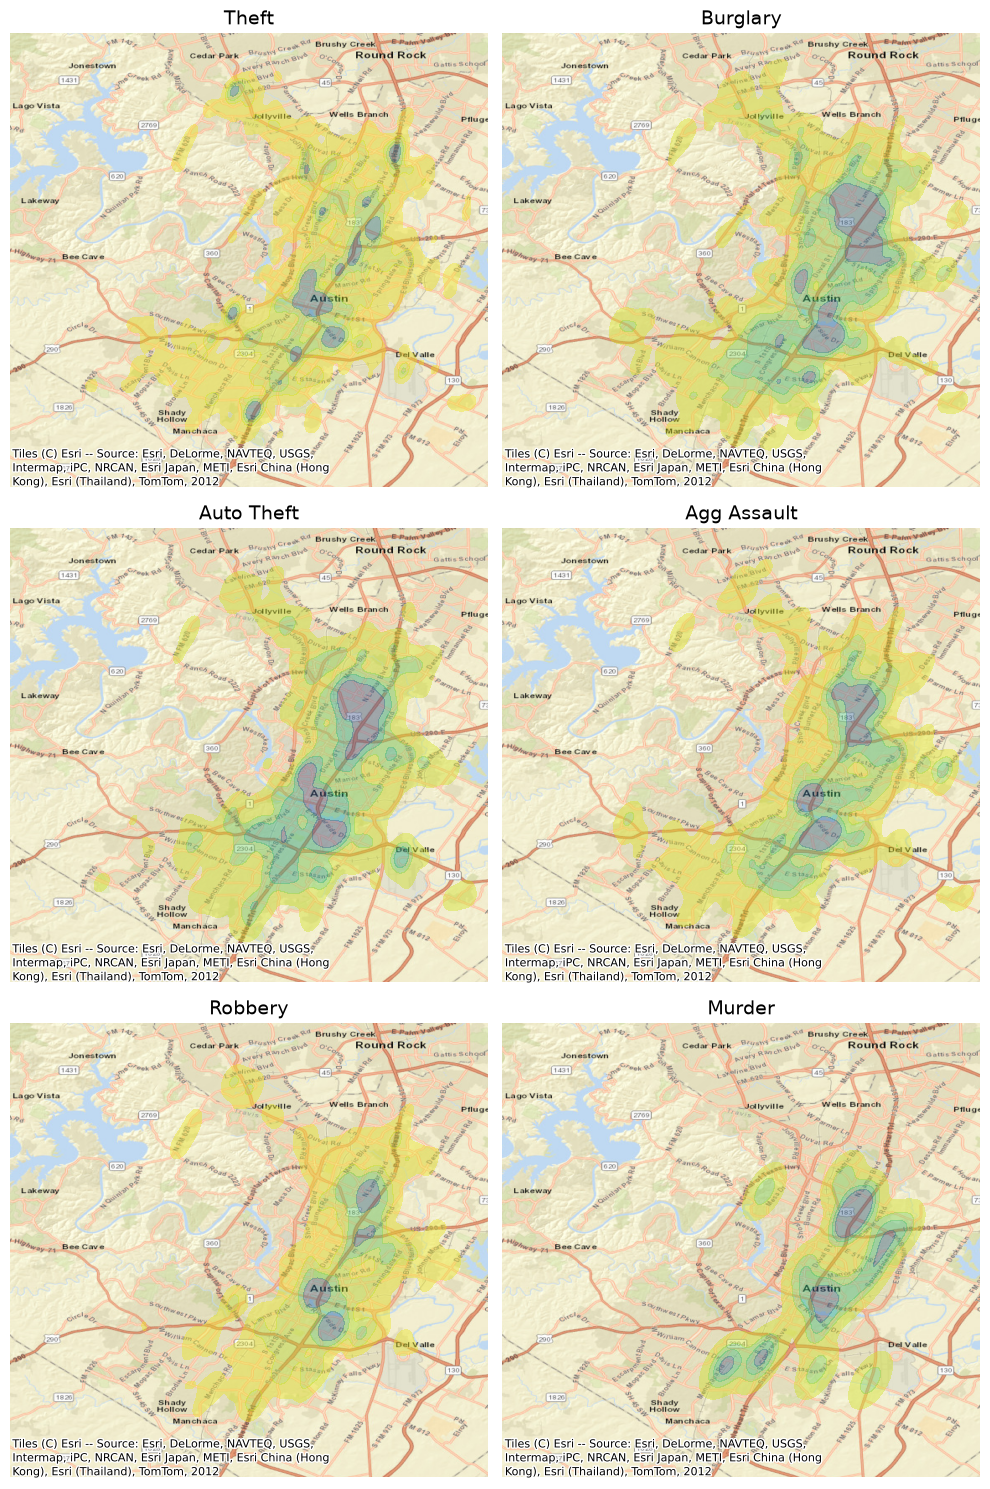

In [ ]:


display_offenses = ['Theft', 'Burglary', 'Auto Theft', 'Agg Assault', 'Robbery', 'Murder']

fig, axes = plt.subplots(3, 2, figsize=(10, 15), sharex=True, sharey=True)
axes = axes.flatten()


for ax, offense in zip(axes, display_offenses):
    subset = gdf[gdf.UCR_Offense == offense]
    plt.sca(ax)
    # plt.scatter(x=subset.Longitude, y=subset.Latitude, c=offense_colors[offense], label=offense, alpha=0.5, s=2)
    sns.kdeplot(
        x=subset['Longitude'],
        y=subset['Latitude'],
        cmap='viridis_r',
        fill=True,
        bw_adjust=0.4,      # lower = tighter heat pockets
        alpha=0.4,
        levels=5
    )
    # ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.Esri.WorldGrayCanvas)
    ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.Esri.WorldStreetMap)
    ax.set_title(f"{offense}", fontsize=14)
    ax.set_axis_off()

# Theft          28274
# Burglary        4927
# Auto Theft      2018
# Agg Assault     1915
# Robbery          935
# Rape             481
# Murder            23

plt.tight_layout()
plt.grid(False)
plt.show()

/var/folders/78/99d7_1kj53qfpwrrlldn78dc0000gn/T/ipykernel_67806/1304551608.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


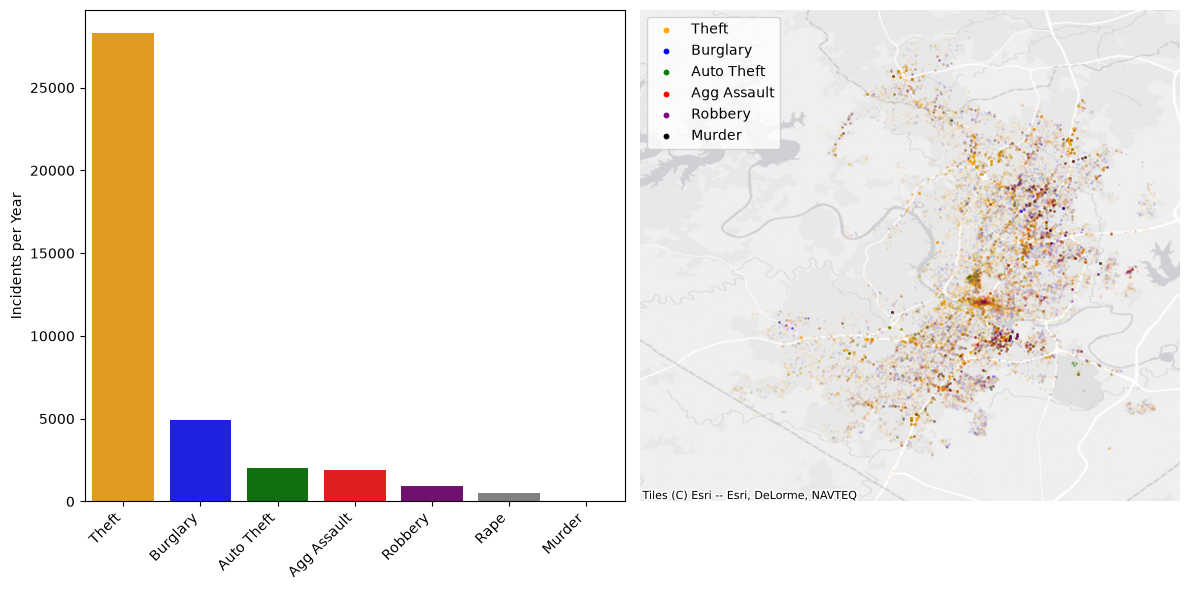

In [243]:

display_offenses = ['Theft', 'Burglary', 'Auto Theft', 'Agg Assault', 'Robbery', 'Murder']
offense_colors = {
        'Theft': 'orange',
        'Burglary': 'blue',
        'Auto Theft': 'green',
        'Agg Assault': 'red',
        'Robbery':'purple',
        'Murder':'black',
    }

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=False, sharey=False)

ax = plt.subplot(1,2,1)
offense_counts = gdf['UCR_Offense'].value_counts()
colors_in_order = [offense_colors.get(offense, "gray") for offense in offense_counts.index]
sns.countplot(
    data=gdf,
    x="UCR_Offense",
    order=gdf["UCR_Offense"].value_counts().index,
    palette=colors_in_order,
)

ax.set_ylabel("Incidents per Year")
ax.set_xlabel("")

plt.xticks(rotation=45, ha="right")
# Theft          28274
# Burglary        4927
# Auto Theft      2018
# Agg Assault     1915
# Robbery          935
# Rape             481
# Murder            23


ax = plt.subplot(1, 2, 2)



for offense in display_offenses:
    subset = gdf[gdf.UCR_Offense == offense]

    plt.scatter(x=subset.Longitude, y=subset.Latitude, c=offense_colors[offense], label=offense, alpha=0.05, s=1)
    # ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.Esri.WorldGrayCanvas)
    ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.Esri.WorldGrayCanvas)
    ax.set_axis_off()

leg = plt.legend()

# Override the legend marker size and opacity
for handle in leg.legend_handles:
    handle.set_sizes([10.0])  # Make the dots larger in the legend (passed as a list)
    handle.set_alpha(1.0)

plt.tight_layout()
plt.grid(False)
plt.show()

## All-Purpose Comparison Heat Map Maker

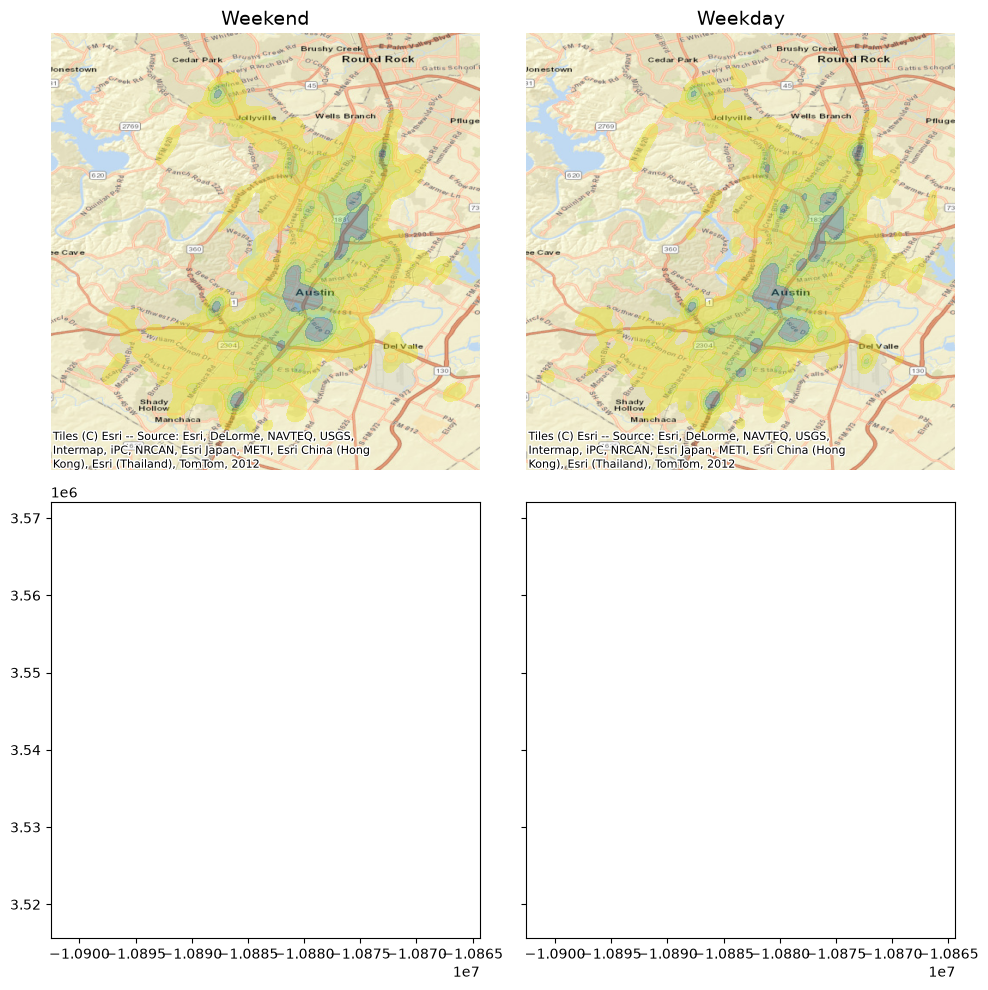

In [223]:
plots = [
            ('Weekend', gdf.Report_Date.dt.day_of_week > 4),
            ('Weekday', gdf.Report_Date.dt.day_of_week <= 4),
            # ('No Rain + Theft', (gdf['UCR_Offense'] == 'Theft') & (gdf['PrecipitationSumInches'] == 0)),
            # ('Rain + Theft', (gdf['UCR_Offense'] == 'Theft') & (gdf['PrecipitationSumInches'] > 0)),
            # ('Temp < 60 + Theft', (gdf['UCR_Offense'] == 'Theft') & (gdf['TempAvgF'] < 60)),
            # ('Temp > 60 + Theft', (gdf['UCR_Offense'] == 'Theft') & (gdf['TempAvgF'] >= 60)),
        ]

##### Do T test on compared conditions #####
# import scipy.stats as st

# condition_col = 'TempHighF'

# daily_df = gdf.groupby('Report_Date').agg(
#     daily_crimes=('Report_Date', 'count'),       # Count incidents
#     condition_val=(condition_col, 'first') # Extract the daily condition
# ).reset_index()

# # Split the daily counts into two groups based on the condition
# threshold = 90
# condition_true = daily_df[daily_df['condition_val'] > threshold]['daily_crimes']
# condition_false = daily_df[daily_df['condition_val'] <= threshold]['daily_crimes']

# # Perform t-test
# t_stat, p_value = st.ttest_ind(condition_true, condition_false, equal_var=False)
# corr, p_value = st.pearsonr(daily_df["daily_crimes"], daily_df["condition_val"])

# print(f"{condition_col} > 90")
# print(f"Mean crimes (Condition True): {condition_true.mean():.2f}")
# print(f"Mean crimes (Condition False): {condition_false.mean():.2f}")

# print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.4f}")
# print(f"Pearson correlation: {corr:.3f}, p-value: {p_value:.5f}")

##### Plot compared KDE's #####

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, plot in zip(axes, plots):
    subset = gdf[plot[1]]
    plt.sca(ax)
    # plt.scatter(x=subset.Longitude, y=subset.Latitude, c='Red', alpha=0.3, s=2)
    # ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.Esri.WorldGrayCanvas)

    # plt.scatter(x=subset.Longitude, y=subset.Latitude, c='Black', alpha=0.2, s=1.5)
    sns.kdeplot(
        x=subset['Longitude'],
        y=subset['Latitude'],
        cmap='viridis_r',
        fill=True,
        bw_adjust=0.4,      # lower = tighter heat pockets
        alpha=0.4,
        levels=5
    )
    ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.Esri.WorldStreetMap)
    ax.set_title(f"{plot[0]}", fontsize=14)
    ax.set_axis_off()

# Theft          28274
# Burglary        4927
# Auto Theft      2018
# Agg Assault     1915
# Robbery          935
# Rape             481
# Murder            23

plt.tight_layout()
plt.grid(False)
plt.show()